## 3-1 Accuracy(정확도)

In [ ]:
import sklearn
# 사이킷런의 버전을 확인하고 출력
print(sklearn.__version__)

1.7.2


In [ ]:
import numpy as np
from sklearn.base import BaseEstimator
# BaseEstimator를 상속받아서 사이킷런의 머신러닝 모델과 똑같이 동작하는 사용자 정의 클래스 생성
class MyDummyClassifier(BaseEstimator):
    # fit( ) 메소드는 아무것도 학습하지 않음.
    # 우리가 정해준 단순한 조건문으로만 작동하기 때문에 fit할 내용이 없다. 
    def fit(self, X , y=None):
        pass
    
    # predict( ) 메소드는 단순히 Sex feature가 1 이면 0 , 그렇지 않으면 1 로 예측함. 
    # 하지만 여기서는 단순히 'Sex(성별)' 피처만 보고 결과를 찍어버림.
    def predict(self, X):
        # 입력된 데이터(X)의 행(row) 개수만큼, 0으로 채워진 1차원 배열(정답을 담을 빈 그릇)을 생성
        # X.shape[0]은 데이터의 총 개수(사람 수)를 의미함
        pred = np.zeros( ( X.shape[0], 1 ))

        # 데이터의 개수만큼 반복문을 돌면서 한 명씩 검사함
        for i in range (X.shape[0]) :
            # i번째 사람의 'Sex' 컬럼 값이 1(일반적으로 남성을 의미)이라면
            if X['Sex'].iloc[i] == 1:
                pred[i] = 0  # 0(사망)으로 예측하여 배열에 저장
            # 1이 아니라면 (즉, 여성이라면)
            else :
                pred[i] = 1 # 1(생존)으로 예측하여 배열에 저장
        
        # 최종적으로 예측된 결과가 담긴 배열을 반환
        return pred


In [ ]:
# 데이터 전처리 단계
from sklearn.preprocessing import LabelEncoder

# Null 처리 함수
def fillna(df):
    # 'Age(나이)' 컬럼의 빈칸은 전체 나이의 평균값(mean)으로 채워 넣음
    # inplace=True를 통해 원본 데이터프레임(df)에 바로 적용함
    df['Age'].fillna(df['Age'].mean(), inplace=True)
    # 'Cabin(선실 번호)' 컬럼의 빈칸은 임의의 문자 'N'으로 채움
    df['Cabin'].fillna('N', inplace=True)
    # 'Embarked(탑승 항구)' 컬럼의 빈칸도 임의의 문자 'N'으로 채움
    df['Embarked'].fillna('N', inplace=True)
    # 'Fare(요금)' 컬럼의 빈칸은 0으로 채움
    df['Fare'].fillna(0, inplace=True)
    return df

# 머신러닝 알고리즘에 불필요한 피처 제거
def drop_features(df):
    df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
    return df

# 레이블 인코딩 수행.
def format_features(df):
    # Cabin(선실 번호)의 경우 'C85', 'B28'처럼 되어 있는데, 
    # 선실의 등급을 나타내는 맨 앞 첫 알파벳(C, B 등) 하나만 추출해서 저장함 (0번째 인덱스부터 1개만)
    df['Cabin'] = df['Cabin'].str[:1]

    # 숫자로 변환해야 할 문자형 컬럼들을 리스트로 묶음
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder()
        le = le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df

# 앞에서 설정한 데이터 전처리 함수 호출
def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)
    return df

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 원본 데이터를 재로딩, 데이터 가공, 학습 데이터/테스트 데이터 분할.
titanic_df = pd.read_csv('./titanic_train.csv')

# 정답지(Label) 분리: 우리가 예측해야 할 'Survived(생존 여부)' 컬럼만 따로 빼서 y에 저장
y_titanic_df = titanic_df['Survived']

# 문제지(Features) 분리: 원본 데이터에서 정답('Survived')을 제외한 나머지 데이터들을 X에 저장
X_titanic_df= titanic_df.drop('Survived', axis=1)

# 앞에서 정의했던 전처리 함수를 호출하여 문제지(X)의 결측치를 채우고, 문자를 숫자로 바꾸는 등 깔끔하게 정리함
X_titanic_df = transform_features(X_titanic_df)

# 2. 학습 데이터 / 테스트 데이터 분할
# 전체 데이터를 '공부용(Train)'과 '시험용(Test)'으로 나눔 (비율은 8:2)
# random_state=0 은 코드를 다시 실행해도 항상 똑같이 랜덤으로 섞이게 고정해주는 역할
X_train, X_test, y_train, y_test=train_test_split(X_titanic_df, y_titanic_df,
                                                  test_size=0.2, random_state=0)

# 3. 모델 학습(fit) 및 예측(predict), 평가(accuracy_score)
# 아까 우리가 만든 '무조건 여자는 살고 남자는 죽는다고 찍는' 가짜 모델 객체 생성
# 위에서 생성한 Dummy Classifier를 이용해 학습/예측/평가 수행.
myclf = MyDummyClassifier()

# 모델 학습 (하지만 우리 모델의 fit 함수는 pass 처리되어 있으므로 아무것도 안 함)
myclf.fit(X_train, y_train)

# 공부하지 않은 시험용 데이터(X_test)를 주고 생존 여부를 예측해보라고 지시함 (결과는 mypredictions에 저장)
mypredictions = myclf.predict(X_test)

# 실제 정답(y_test)과 모델이 예측한 값(mypredictions)을 비교하여 얼마나 맞췄는지 '정확도(Accuracy)'를 계산하고 출력함
print('Dummy Classifier의 정확도는: {0:.4f}'.format(accuracy_score(y_test, mypredictions)))

Dummy Classifier의 정확도는: 0.7877


In [4]:
# 손글씨 숫자 이미지 데이터를 불러오는 함수
from sklearn.datasets import load_digits

from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

# 1. 이전 타이타닉 예제처럼 사이킷런 규칙(BaseEstimator)을 따르는 가짜(Fake) 모델 생성
class MyFakeClassifier(BaseEstimator):
    # 학습(fit) 과정은 아무것도 하지 않고 패스합니다. (규칙을 지키기 위한 빈껍데기)
    def fit(self,X,y):
        pass
    
    # 입력값으로 들어오는 X 데이터 셋의 크기만큼 모두 0값으로 만들어서 반환
    def predict(self,X):
        return np.zeros( (len(X), 1) , dtype=bool)

# 사이킷런의 내장 데이터 셋인 load_digits( )를 이용하여 MNIST 데이터 로딩
digits = load_digits()

# 3. 불러온 데이터의 실제 형태 확인하기
# 이미지의 픽셀 값들이 숫자로 변환된 데이터(문제지)를 출력함
print(digits.data)

# 데이터의 크기(형태) 출력: 보통 (1797, 64)가 나옴. 
# 즉, 1797장의 이미지 데이터가 있고, 각 이미지는 64개(8x8 픽셀)의 특징으로 이루어져 있다는 뜻
print("### digits.data.shape:", digits.data.shape)
print(digits.target)
print("### digits.target.shape:", digits.target.shape)

[[ 0.  0.  5. ...  0.  0.  0.]
 [ 0.  0.  0. ... 10.  0.  0.]
 [ 0.  0.  0. ... 16.  9.  0.]
 ...
 [ 0.  0.  1. ...  6.  0.  0.]
 [ 0.  0.  2. ... 12.  0.  0.]
 [ 0.  0. 10. ... 12.  1.  0.]]
### digits.data.shape: (1797, 64)
[0 1 2 ... 8 9 8]
### digits.target.shape: (1797,)


In [ ]:
# 1797개의 숫자를 훑으면서 7인지 묻고 7이면 Ture, 아니면 False로 바꿈
# 머신러닝의 문제를 다중분류에서 이진 분류로 바꾸는 핵심 역할
digits.target == 7


array([False, False, False, ..., False, False, False], shape=(1797,))

In [6]:
# 1. 정답지(Label)를 기계가 좋아하는 숫자(1과 0)로 변환
# digits번호가 7번이면 True이고 이를 astype(int)로 1로 변환, 7번이 아니면 False이고 0으로 변환. 
y = (digits.target == 7).astype(int)

# 2. 학습용/시험용 데이터 분할
# 원본 이미지 데이터(digits.data)와 방금 1과 0으로 만든 편파적인 정답지(y)를 
# train_test_split을 이용해 학습 데이터(Train)와 테스트 데이터(Test)로 나눔
# random_state=11은 데이터를 섞을 때 항상 똑같은 방식으로 섞이도록 기준을 잡아주는 역할
X_train, X_test, y_train, y_test = train_test_split( digits.data, y, random_state=11)

In [ ]:
# 불균형한 레이블 데이터 분포도 확인. 
print('레이블 테스트 세트 크기 :', y_test.shape)
print('테스트 세트 레이블 0 과 1의 분포도')
# 판다스의 value_counts()를 사용해 y_test 안에 0(7이 아님)과 1(7임)이 각각 몇 개씩 있는지 셉니다.
# (출력해보면 0이 약 400개, 1이 약 45개 정도로 0이 압도적으로 많다는 것을 알 수 있습니다.)
print(pd.Series(y_test).value_counts())

# Dummy Classifier로 학습/예측/정확도 평가
fakeclf = MyFakeClassifier()
fakeclf.fit(X_train , y_train)
fakepred = fakeclf.predict(X_test)
print('모든 예측을 0으로 하여도 정확도는:{:.3f}'.format(accuracy_score(y_test , fakepred)))

레이블 테스트 세트 크기 : (450,)
테스트 세트 레이블 0 과 1의 분포도
0    405
1     45
Name: count, dtype: int64
모든 예측을 0으로 하여도 정확도는:0.900


## Confusion Matrix(오차 행렬)

In [ ]:
from sklearn.metrics import confusion_matrix

# 앞절의 예측 결과인 fakepred와 실제 결과인 y_test의 Confusion Matrix출력
# 실제 결과인 y_test(실제 정답지)를 비교하여 Confusion Matrix(오차 행렬)를 출력함.
# 이를 통해 모델이 정답을 맞혔다면 어떻게 맞혔는지, 틀렸다면 어떻게 틀렸는지 세부적인 내역을 확인할 수 있음.
confusion_matrix(y_test , fakepred)

# 아래 행렬은 TN(실제 0을 0으로 잘맞춤), FP(실제 0인데 1로 잘못 찍음)
#            FN(실제 1인데 0으로 잘못 찍음), TP(실제 1을 1로 잘 맞춤)
# 의 자리를 가진 행렬이다

array([[405,   0],
       [ 45,   0]])

## 정밀도(Precision) 과 재현율(Recall)

**MyFakeClassifier의 예측 결과로 정밀도와 재현율 측정**

In [ ]:
# 정확도, 정밀도, 재현율을 계산해주는 사이킷런의 채점 도구들을 불러옵니다
from sklearn.metrics import accuracy_score, precision_score , recall_score

# 1. 정밀도(Precision) 출력 TP / (FP + TP) 
# 모델이 1이라고 에측한 것 중에서 실제로 1인 것의 비율
# 이 모델은 애초에 1이라고 말한적이 없음 (전부 0으로만 찍었었다)
# 실제 정답(y_test)과 가짜 모델의 0번 찍기 답안지(fakepred)를 비교해 정밀도를 계산합니다.
# 결과는 0.0 이 나옵니다.
print("정밀도:", precision_score(y_test, fakepred))

# 2. 재현율(Recall) 출력 TP / (FN + TP)
# 실제로 1인 데이터 중에서 모델이 놓치지 않고 1이다라고 찾아낸 비율
# 시험지에는 실제로 1인 문제가 45개나 있었는데 다 0으로 밀어서 0으로 나온다.
# 동일하게 실제 정답과 모델의 예측값을 비교해 재현율을 계산합니다.
# 결과 역시 0.0 이 나옵니다.
print("재현율:", recall_score(y_test, fakepred))

정밀도: 0.0
재현율: 0.0


c:\Users\Sanghyeon\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


**오차행렬, 정확도, 정밀도, 재현율을 한꺼번에 계산하는 함수 생성**

In [10]:
from sklearn.metrics import accuracy_score, precision_score , recall_score , confusion_matrix
# 오차행렬, 정확도, 정밀도, 재현율을 따로따로 치기 귀찮으니까 한번에 묶어서 함수 생성
def get_clf_eval(y_test , pred):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred)
    recall = recall_score(y_test , pred)
    print('오차 행렬')
    print(confusion)
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}'.format(accuracy , precision ,recall))

In [ ]:
# 더미 모델을 버리고 실제 머신러닝 모델을 사용해 예측하고 평가하기

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split 

# 로지스틱 회귀모델 불러오기
from sklearn.linear_model import LogisticRegression

# 원본 데이터를 재로딩, 데이터 가공, 학습데이터/테스트 데이터 분할. 
titanic_df = pd.read_csv('./titanic_train.csv')
y_titanic_df = titanic_df['Survived']
X_titanic_df= titanic_df.drop('Survived', axis=1)
X_titanic_df = transform_features(X_titanic_df)

X_train, X_test, y_train, y_test = train_test_split(X_titanic_df, y_titanic_df, \
                                                    test_size=0.20, random_state=11)

lr_clf = LogisticRegression(solver='liblinear')

lr_clf.fit(X_train , y_train)
pred = lr_clf.predict(X_test)
get_clf_eval(y_test , pred)

오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705


C:\Users\Sanghyeon\AppData\Local\Temp\ipykernel_21152\340051843.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
C:\Users\Sanghyeon\AppData\Local\Temp\ipykernel_21152\340051843.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

### Precision/Recall Trade-off

**predict_proba( ) 메소드 확인**

In [ ]:
# 1. predict_proba(): 단순한 최종 결과(0, 1)가 아니라, '확률(Probability)'을 계산해 주는 함수
# 각 승객마다 [0(사망)일 확률, 1(생존)일 확률]을 소수점으로 계산해서 반환함
pred_proba = lr_clf.predict_proba(X_test)

# 2. predict(): 계산된 확률을 바탕으로 최종 결과(0 또는 1)를 예측함
pred  = lr_clf.predict(X_test)

# 확률을 담은 배열의 크기 확인 (예: 179명의 데이터라면, 각 사람마다 2개의 확률값이 나오므로 [179, 2] 형태가 됨
print('pred_proba()결과 Shape : {0}'.format(pred_proba.shape))
# 전체 데이터는 너무 많으니, 맨 앞의 3명(3줄) 데이터만 샘플로 뽑아서 어떻게 생겼는지 확인
print('pred_proba array에서 앞 3개만 샘플로 추출 \n:', pred_proba[:3])

# 예측 확률 array 와 예측 결과값 array 를 concatenate 하여 예측 확률과 결과값을 한눈에 확인
# pred는 원래 1차원 배열[0, 1, 0...]인데, 이걸 세로로 길게 세우기 위해 reshape(-1, 1)을 해줌
pred_proba_result = np.concatenate([pred_proba , pred.reshape(-1,1)],axis=1)

# 합쳐진 배열의 맨 앞 3개를 출력해봄
# [0일 확률, 1일 확률, 최종 예측값] 형태로 출력되며, 정말로 더 높은 확률 쪽으로 손을 들어줬는지 눈으로 확인 가능
print('두개의 class 중에서 더 큰 확률을 클래스 값으로 예측 \n',pred_proba_result[:3])


pred_proba()결과 Shape : (179, 2)
pred_proba array에서 앞 3개만 샘플로 추출 
: [[0.44935228 0.55064772]
 [0.86335513 0.13664487]
 [0.86429646 0.13570354]]
두개의 class 중에서 더 큰 확률을 클래스 값으로 예측 
 [[0.44935228 0.55064772 1.        ]
 [0.86335513 0.13664487 0.        ]
 [0.86429646 0.13570354 0.        ]]


**Binarizer 활용**

In [ ]:
# Binarizer로 내가 원하는 기준(Threshold)을 정해놓기
from sklearn.preprocessing import Binarizer

X = [[ 1, -1,  2],
     [ 2,  0,  0],
     [ 0,  1.1, 1.2]]

# threshold 기준값보다 같거나 작으면 0을, 크면 1을 반환
binarizer = Binarizer(threshold=1.1)                     
print(binarizer.fit_transform(X))

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]


**분류 결정 임계값 0.5 기반에서 Binarizer를 이용하여 예측값 변환**

In [ ]:
from sklearn.preprocessing import Binarizer

#Binarizer의 threshold 설정값. 분류 결정 임곗값임.  
custom_threshold = 0.5

# predict_proba( ) 반환값의 두번째 컬럼 , 즉 Positive 클래스 컬럼 하나만 추출하여 Binarizer를 적용
# 2. 생존 확률(Positive 클래스, 1)만 쏙 뽑아내기
# pred_proba는 [사망 확률, 생존 확률] 두 개의 컬럼으로 되어 있음
# [:, 1]은 모든 데이터(행)에 대해 두 번째 컬럼(인덱스 1, 즉 생존 확률)만 가져오라는 뜻입니다.
# reshape(-1, 1)은 가져온 데이터를 세로로 길쭉한 2차원 배열(형태)로 만들어 줍니다. (Binarizer가 2차원 배열을 요구하기 때문)
pred_proba_1 = pred_proba[:,1].reshape(-1,1)

# 3. 우리가 만든 생존 확률 데이터에 Binarizer(기준점 0.5)를 적용합니다.
# 생존 확률이 0.5보다 작거나 같으면 0(사망)으로, 0.5보다 크면 1(생존)로 변환됩니다.
binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_1) 
custom_predict = binarizer.transform(pred_proba_1)

get_clf_eval(y_test, custom_predict)



오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705


**분류 결정 임계값 0.4 기반에서 Binarizer를 이용하여 예측값 변환**

In [ ]:
# Binarizer의 threshold 설정값을 0.4로 설정. 즉 분류 결정 임곗값을 0.5에서 0.4로 낮춤  
custom_threshold = 0.4
pred_proba_1 = pred_proba[:,1].reshape(-1,1)
binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_1) 
custom_predict = binarizer.transform(pred_proba_1)

get_clf_eval(y_test , custom_predict)
# Threshold를 낮추면 모델이 positive(1)로 예측하는 횟수가 많아져 재현율은 올라가지만, 
# 그만큼 잘못 예측하는 것도 많아져 정밀도는 떨어진다,
# 이처럼 정밀도와 재현율이 반대로 움직이는 현상을
# 정밀도/재현율 Trade Off라고 한다.

오차 행렬
[[97 21]
 [11 50]]
정확도: 0.8212, 정밀도: 0.7042, 재현율: 0.8197


**여러개의 분류 결정 임곗값을 변경하면서  Binarizer를 이용하여 예측값 변환**

In [16]:
# 테스트를 수행할 모든 임곗값을 리스트 객체로 저장. 
thresholds = [0.4, 0.45, 0.50, 0.55, 0.60]

def get_eval_by_threshold(y_test , pred_proba_c1, thresholds):
    # thresholds list객체내의 값을 차례로 iteration하면서 Evaluation 수행.
    for custom_threshold in thresholds:
        binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_c1) 
        custom_predict = binarizer.transform(pred_proba_c1)
        print('임곗값:',custom_threshold)
        get_clf_eval(y_test , custom_predict)

get_eval_by_threshold(y_test ,pred_proba[:,1].reshape(-1,1), thresholds )

임곗값: 0.4
오차 행렬
[[97 21]
 [11 50]]
정확도: 0.8212, 정밀도: 0.7042, 재현율: 0.8197
임곗값: 0.45
오차 행렬
[[105  13]
 [ 13  48]]
정확도: 0.8547, 정밀도: 0.7869, 재현율: 0.7869
임곗값: 0.5
오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705
임곗값: 0.55
오차 행렬
[[111   7]
 [ 16  45]]
정확도: 0.8715, 정밀도: 0.8654, 재현율: 0.7377
임곗값: 0.6
오차 행렬
[[113   5]
 [ 17  44]]
정확도: 0.8771, 정밀도: 0.8980, 재현율: 0.7213


**precision_recall_curve( ) 를 이용하여 임곗값에 따른 정밀도-재현율 값 추출**

In [17]:
from sklearn.metrics import precision_recall_curve

# 레이블 값이 1일때의 예측 확률을 추출 
pred_proba_class1 = lr_clf.predict_proba(X_test)[:, 1] 

# 실제값 데이터 셋과 레이블 값이 1일 때의 예측 확률을 precision_recall_curve 인자로 입력 
precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_class1 )
print('반환된 분류 결정 임곗값 배열의 Shape:', thresholds.shape)
print('반환된 precisions 배열의 Shape:', precisions.shape)
print('반환된 recalls 배열의 Shape:', recalls.shape)

print("thresholds 5 sample:", thresholds[:5])
print("precisions 5 sample:", precisions[:5])
print("recalls 5 sample:", recalls[:5])

#반환된 임계값 배열 로우가 147건이므로 샘플로 10건만 추출하되, 임곗값을 15 Step으로 추출. 
thr_index = np.arange(0, thresholds.shape[0], 15)
print('샘플 추출을 위한 임계값 배열의 index 10개:', thr_index)
print('샘플용 10개의 임곗값: ', np.round(thresholds[thr_index], 2))

# 15 step 단위로 추출된 임계값에 따른 정밀도와 재현율 값 
print('샘플 임계값별 정밀도: ', np.round(precisions[thr_index], 3))
print('샘플 임계값별 재현율: ', np.round(recalls[thr_index], 3))

반환된 분류 결정 임곗값 배열의 Shape: (165,)
반환된 precisions 배열의 Shape: (166,)
반환된 recalls 배열의 Shape: (166,)
thresholds 5 sample: [0.01974987 0.06956413 0.08402807 0.08474207 0.0892016 ]
precisions 5 sample: [0.34078212 0.34269663 0.34463277 0.34659091 0.34857143]
recalls 5 sample: [1. 1. 1. 1. 1.]
샘플 추출을 위한 임계값 배열의 index 10개: [  0  15  30  45  60  75  90 105 120 135 150]
샘플용 10개의 임곗값:  [0.02 0.11 0.13 0.14 0.16 0.24 0.32 0.45 0.62 0.73 0.87]
샘플 임계값별 정밀도:  [0.341 0.372 0.401 0.44  0.505 0.598 0.688 0.774 0.915 0.968 0.938]
샘플 임계값별 재현율:  [1.    1.    0.967 0.902 0.902 0.902 0.869 0.787 0.705 0.492 0.246]


**임곗값의 변경에 따른 정밀도-재현율 변화 곡선을 그림**

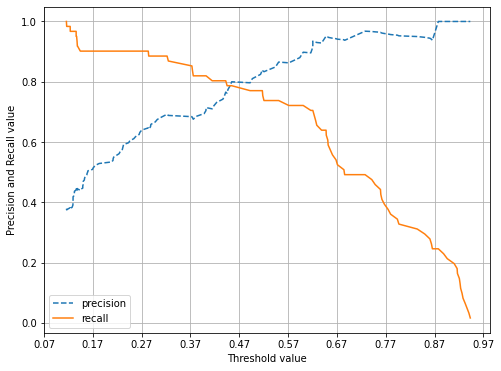

In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

def precision_recall_curve_plot(y_test , pred_proba_c1):
    # threshold ndarray와 이 threshold에 따른 정밀도, 재현율 ndarray 추출. 
    precisions, recalls, thresholds = precision_recall_curve( y_test, pred_proba_c1)
    
    # X축을 threshold값으로, Y축은 정밀도, 재현율 값으로 각각 Plot 수행. 정밀도는 점선으로 표시
    plt.figure(figsize=(8,6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary],label='recall')
    
    # threshold 값 X 축의 Scale을 0.1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1),2))
    
    # x축, y축 label과 legend, 그리고 grid 설정
    plt.xlabel('Threshold value'); plt.ylabel('Precision and Recall value')
    plt.legend(); plt.grid()
    plt.show()
    
precision_recall_curve_plot( y_test, lr_clf.predict_proba(X_test)[:, 1] )


### 3.4 F1 Score

In [ ]:
# 정밀도/재현율 Trade Off때문에 이 두 수치를 공평하게 섞어서 하나의 점수로 만든것
# F1 Score = 2 * 정밀도*재현율/ 정밀도+재현율 (정밀도와 재현율의 조화평균) (너무 한쪽으로 안쏠리게)
from sklearn.metrics import f1_score 
f1 = f1_score(y_test , pred)
print('F1 스코어: {0:.4f}'.format(f1))


F1 스코어: 0.7966


In [ ]:
def get_clf_eval(y_test , pred):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred)
    recall = recall_score(y_test , pred)
    # F1 스코어 추가
    f1 = f1_score(y_test,pred)
    print('오차 행렬')
    print(confusion)
    # f1 score print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, F1:{3:.4f}'.format(accuracy, precision, recall, f1))

# 2. 여러 임곗값을 한 번에 테스트하기 위한 준비
# 테스트해보고 싶은 임곗값(기준점)들을 리스트로 쭉 적어둡니다. (0.4부터 0.6까지 0.05 단위로 5개)
thresholds = [0.4 , 0.45 , 0.50 , 0.55 , 0.60]

# 로지스틱 회귀 모델을 통해 테스트 데이터(X_test)의 생존 확률을 뽑아옵니다.
pred_proba = lr_clf.predict_proba(X_test)
get_eval_by_threshold(y_test, pred_proba[:,1].reshape(-1,1), thresholds)


임곗값: 0.4
오차 행렬
[[97 21]
 [11 50]]
정확도: 0.8212, 정밀도: 0.7042, 재현율: 0.8197, F1:0.7576
임곗값: 0.45
오차 행렬
[[105  13]
 [ 13  48]]
정확도: 0.8547, 정밀도: 0.7869, 재현율: 0.7869, F1:0.7869
임곗값: 0.5
오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705, F1:0.7966
임곗값: 0.55
오차 행렬
[[111   7]
 [ 16  45]]
정확도: 0.8715, 정밀도: 0.8654, 재현율: 0.7377, F1:0.7965
임곗값: 0.6
오차 행렬
[[113   5]
 [ 17  44]]
정확도: 0.8771, 정밀도: 0.8980, 재현율: 0.7213, F1:0.8000


## 3-5 ROC Curve와 AUC

In [22]:
from sklearn.metrics import roc_curve

# 레이블 값이 1일때의 예측 확률을 추출 
pred_proba_class1 = lr_clf.predict_proba(X_test)[:, 1] 

# 2. roc_curve() 함수를 사용해 실제 정답(y_test)과 예측 확률을 넣습니다.
# 이 함수는 임곗값을 변화시키면서 그때의 FPR, TPR, 임곗값 배열을 싹 다 계산해서 반환해 줍니다

fprs , tprs , thresholds = roc_curve(y_test, pred_proba_class1)
# 반환된 임곗값 배열에서 샘플로 데이터를 추출하되, 임곗값을 5 Step으로 추출. 
# thresholds[0]은 max(예측확률)+1로 임의 설정됨. 이를 제외하기 위해 np.arange는 1부터 시작
thr_index = np.arange(1, thresholds.shape[0], 5)
print('샘플 추출을 위한 임곗값 배열의 index:', thr_index)
print('샘플 index로 추출한 임곗값: ', np.round(thresholds[thr_index], 2))

# 5 step 단위로 추출된 임계값에 따른 FPR, TPR 값
# TPR (True Positive Rate = 진짜 양성 비율)
# 실제 생존자 (1) 중에서 모델이 진짜로 생존했다고 잘 맞춘 비율 = 재현율
# FPR (False Positive Rate = 거짓 양성 비율)
# 실제로는 사망자(0)인데 모델이 생존(1)했다라고 판단한 비율
# 임곗값이 낮아질수록 기준이 널널해지니까 TPR상승, FPR상승
print('샘플 임곗값별 FPR: ', np.round(fprs[thr_index], 3))
print('샘플 임곗값별 TPR: ', np.round(tprs[thr_index], 3))


샘플 추출을 위한 임곗값 배열의 index: [ 1  6 11 16 21 26 31 36 41 46]
샘플 index로 추출한 임곗값:  [0.94 0.73 0.62 0.52 0.44 0.28 0.15 0.14 0.13 0.12]
샘플 임곗값별 FPR:  [0.    0.008 0.025 0.076 0.127 0.254 0.576 0.61  0.746 0.847]
샘플 임곗값별 TPR:  [0.016 0.492 0.705 0.738 0.803 0.885 0.902 0.951 0.967 1.   ]


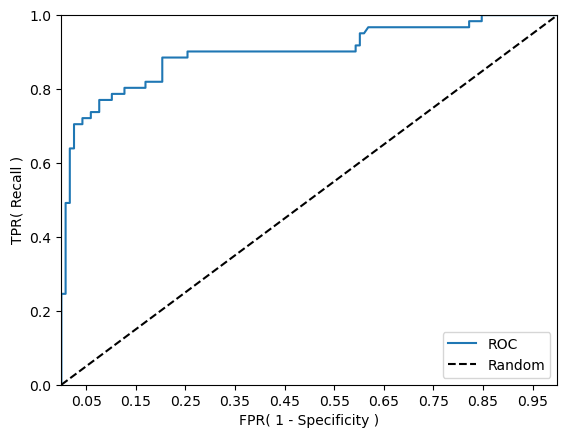

In [24]:
import matplotlib.pyplot as plt
import numpy as np
def roc_curve_plot(y_test , pred_proba_c1):
    # 임곗값에 따른 FPR, TPR 값을 반환 받음. 
    fprs , tprs , thresholds = roc_curve(y_test ,pred_proba_c1)

    # ROC Curve를 plot 곡선으로 그림. 
    plt.plot(fprs , tprs, label='ROC')
    # 가운데 대각선 직선을 그림. 
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    
    # FPR X 축의 Scale을 0.1 단위로 변경, X,Y 축명 설정등   
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1),2))
    plt.xlim(0,1); plt.ylim(0,1)
    plt.xlabel('FPR( 1 - Specificity )'); plt.ylabel('TPR( Recall )')
    plt.legend()
    plt.show()
    
roc_curve_plot(y_test, lr_clf.predict_proba(X_test)[:, 1] )


In [ ]:
from sklearn.metrics import roc_auc_score

# 1. 모델이 예측한 생존 확률(레이블 값이 1일 때의 확률)을 추출
pred_proba = lr_clf.predict_proba(X_test)[:, 1]

# 2. 실제 정답(y_test)과 모델의 생존 예측 확률(pred_proba)을 roc_auc_score 함수에 넣기
#  이 함수는 ROC 곡선 밑의 면적(AUC)을 계산하여 하나의 숫자로 반환해 줌
roc_score = roc_auc_score(y_test, pred_proba)
print('ROC AUC 값: {0:.4f}'.format(roc_score))
# ROC AUC 값이 0.8이 넘어가면 성능이 아주 훌륭한 모델


ROC AUC 값: 0.8987


In [26]:
def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred)
    recall = recall_score(y_test , pred)
    f1 = f1_score(y_test,pred)
    # ROC-AUC 추가 
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
          F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))
